In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Set visual aesthetic for seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Ensure images directory exists
os.makedirs('../images', exist_ok=True)

In [2]:
# Load the data
df = pd.read_csv('../data/StudentsPerformance.csv')
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe(include='all'))

Dataset Shape: (1000, 8)

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data Types:
 gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Summary Statistics:
         gender race/ethnicity parental level of education     lunch  \
count     1000           1000                        1000      1000   
unique       2              5                           6         2   
top     female        group C                some college  standard   
freq       518            319                         226       645   
mean       NaN            NaN                         NaN       NaN   
std        NaN            NaN                    

In [4]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


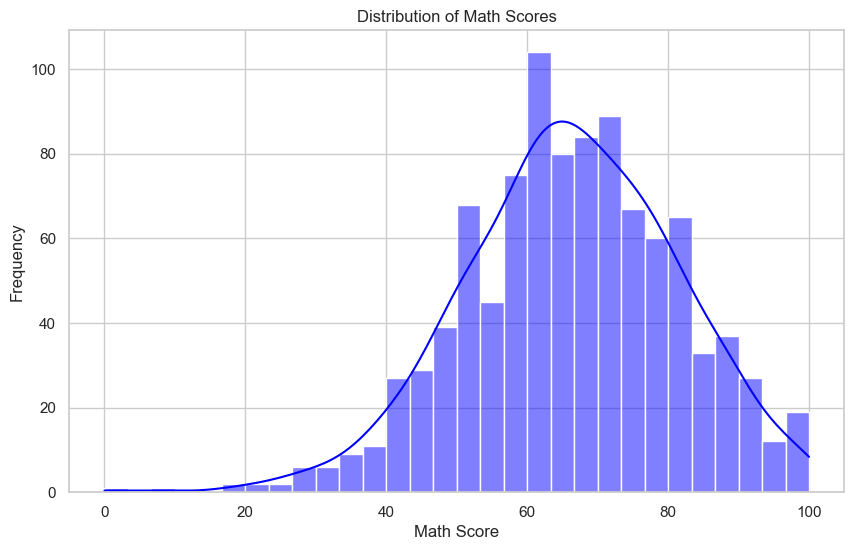

In [5]:
# 1. Math Score Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['math score'], bins=30, kde=True, color='blue')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.savefig('../images/math_score_distribution.png', bbox_inches='tight')
plt.show()

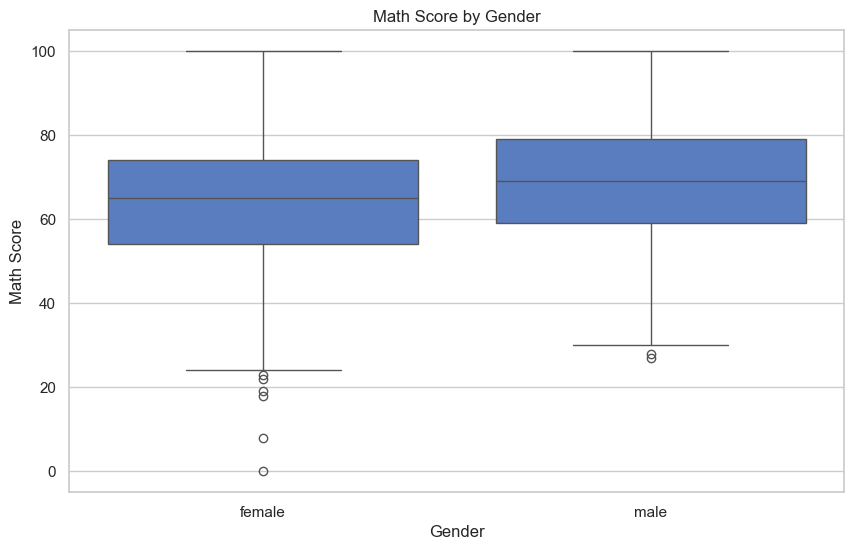

In [6]:
# 2. Gender vs Math Score (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='math score', data=df)
plt.title('Math Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Math Score')
plt.savefig('../images/gender_vs_score.png', bbox_inches='tight')
plt.show()

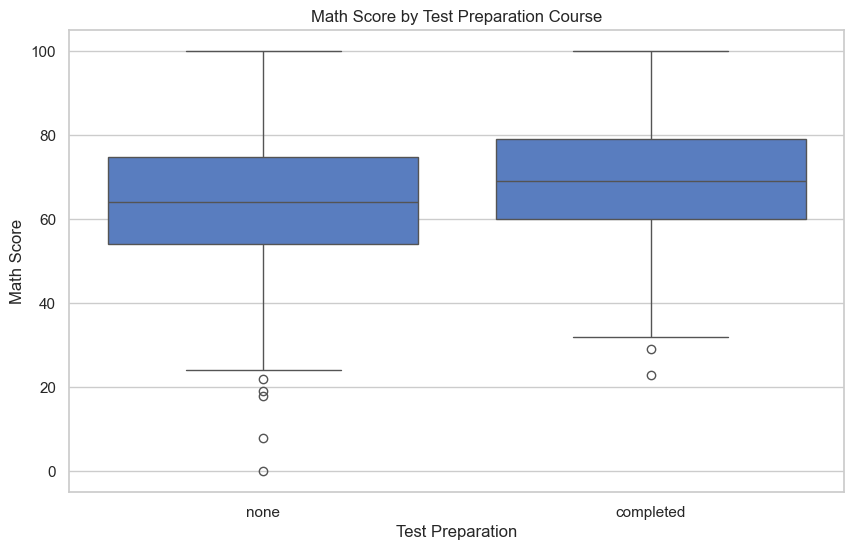

In [7]:
# 3. Test Preparation vs Math Score (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title('Math Score by Test Preparation Course')
plt.xlabel('Test Preparation')
plt.ylabel('Math Score')
plt.savefig('../images/testprep_vs_score.png', bbox_inches='tight')
plt.show()

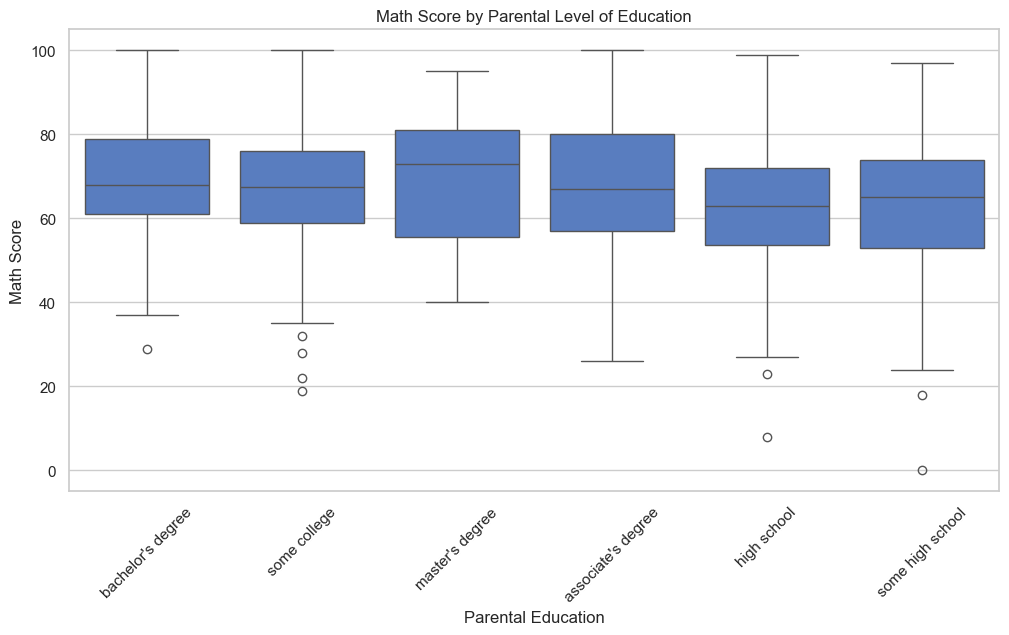

In [8]:
# 4. Parental Education vs Math Score (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='parental level of education', y='math score', data=df)
plt.title('Math Score by Parental Level of Education')
plt.xlabel('Parental Education')
plt.ylabel('Math Score')
plt.xticks(rotation=45)
plt.savefig('../images/parental_education_vs_score.png', bbox_inches='tight')
plt.show()

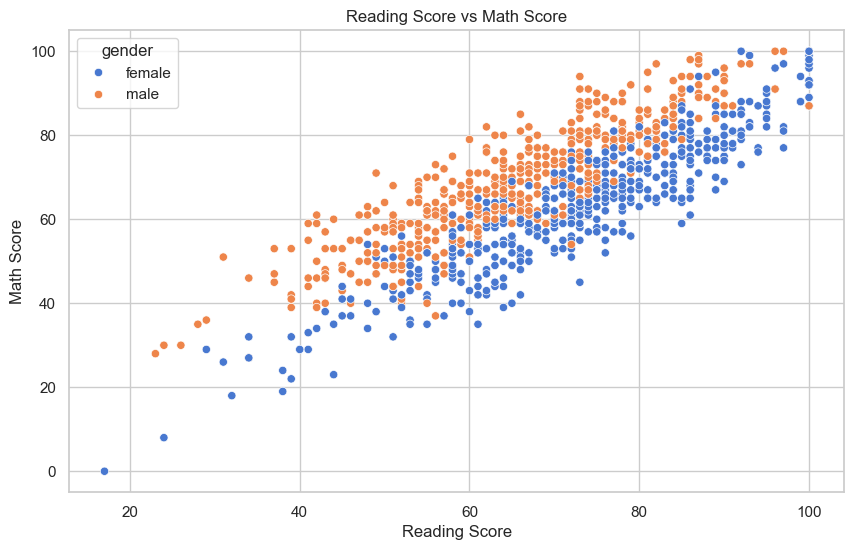

In [9]:
# 5. Scatter Plot: Reading vs Math Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='reading score', y='math score', hue='gender', data=df)
plt.title('Reading Score vs Math Score')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.savefig('../images/scatter_reading_vs_math.png', bbox_inches='tight')
plt.show()

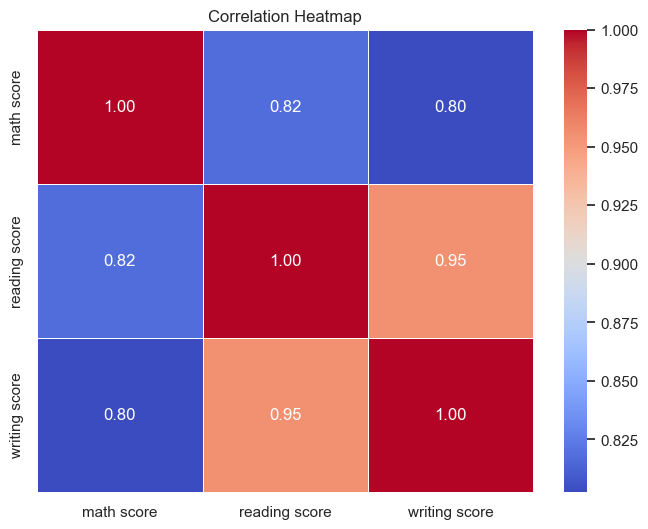

In [10]:
# 6. Correlation Heatmap (Numerical columns only)
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../images/heatmap.png', bbox_inches='tight')
plt.show()

In [11]:
# No missing values were found, but let's drop them just in case
df = df.dropna()

# We will predict 'math score'. Let's isolate our target variable and feature matrix.
target = 'math score'
X = df.drop(columns=[target])
y = df[target]

# One-Hot Encoding for categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)
print("Encoded Feature Matrix Shape:", X_encoded.shape)
X_encoded.head()

Encoded Feature Matrix Shape: (1000, 14)


,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Standardize the numerical features (reading score, writing score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (800, 14)
Testing data shape: (200, 14)


In [13]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.


Random Forest trained successfully.


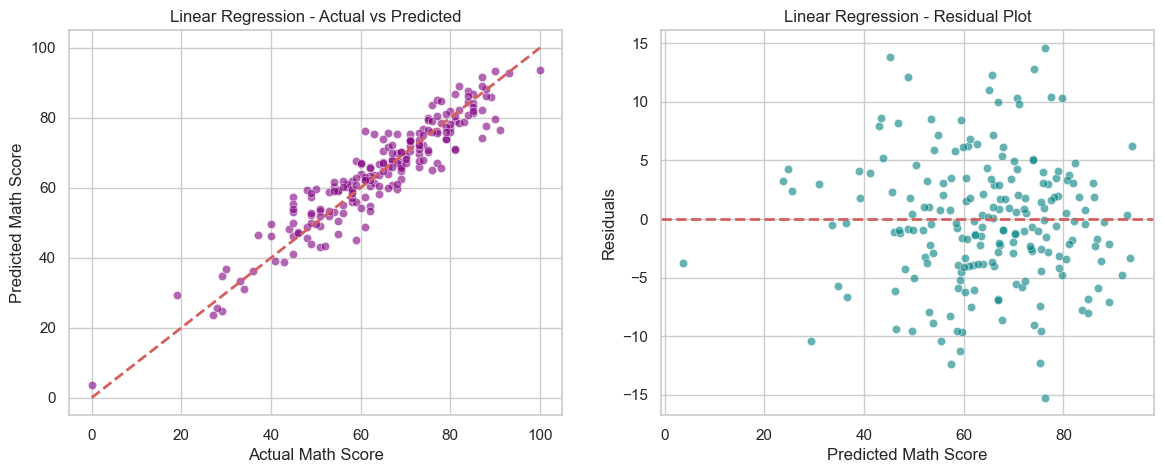

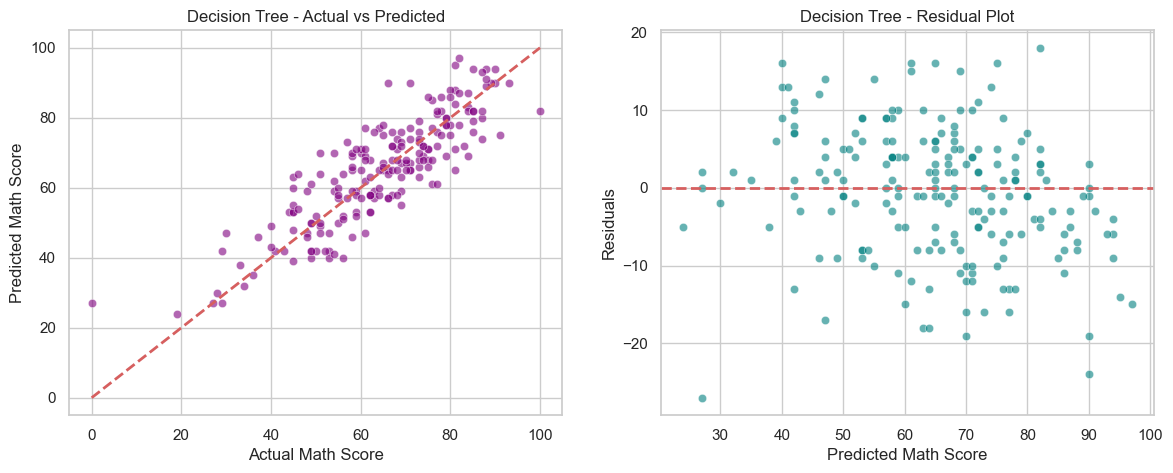

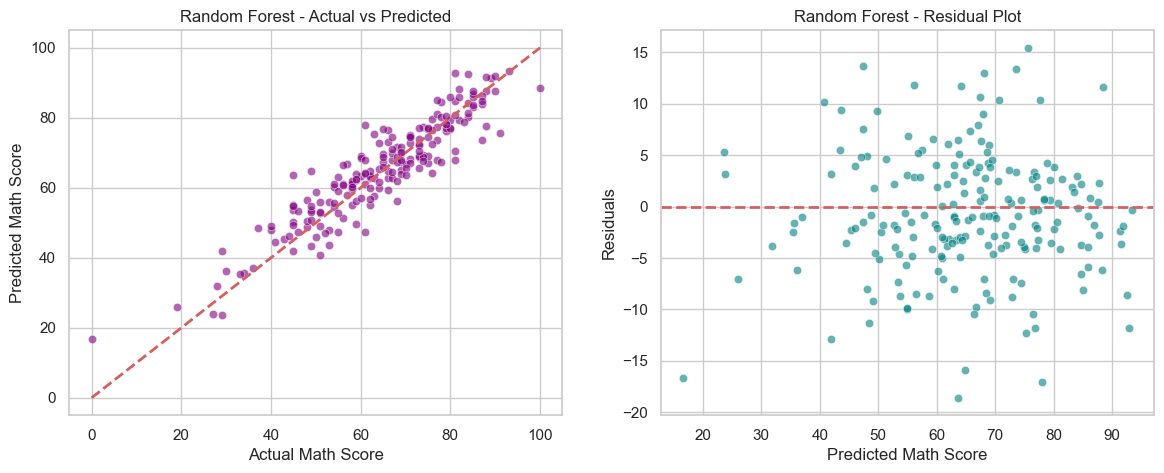

In [15]:
for name in models.keys():
    y_pred = predictions[name]
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Predicted vs Actual
    sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.6, color='purple')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_title(f'{name} - Actual vs Predicted')
    axes[0].set_xlabel('Actual Math Score')
    axes[0].set_ylabel('Predicted Math Score')
    
    # Residual Plot
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.6, color='teal')
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_title(f'{name} - Residual Plot')
    axes[1].set_xlabel('Predicted Math Score')
    axes[1].set_ylabel('Residuals')
    
    filename = name.lower().replace(' ', '_')
    plt.savefig(f'../images/{filename}_evaluation.png', bbox_inches='tight')
    plt.show()

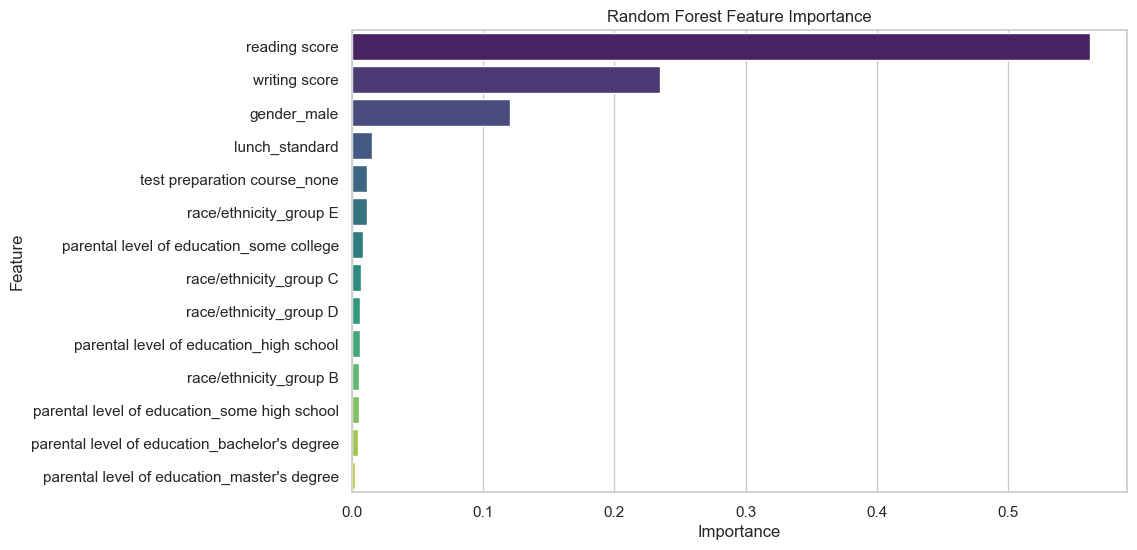

In [16]:
# Feature Importance for Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.savefig('../images/feature_importance.png', bbox_inches='tight')
plt.show()